In [1]:
from itertools import chain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#import itertools as chain

sns.set(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
csv_path = r'C:\Users\srbuh\Desktop\Medical_AI_Diagnosis\data\Data_Entry_2017.csv'
df = pd.read_csv(csv_path)

print(f"Number of images: {len(df)}")
df.head()

Number of images: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


Data Cleaning

In [7]:
import itertools

# Delete unimportant columns, save only important ones
df = df[['Image Index', 'Finding Labels', 'Patient ID']]

# Unique labels
all_labels = list(itertools.chain.from_iterable(df['Finding Labels'].map(lambda x: x.split('|')).tolist()))
unique_labels = sorted(list(set(all_labels)))

print(f"types of diseases ({len(unique_labels)}): ")
print(unique_labels)

types of diseases (15): 
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


Class Distribution

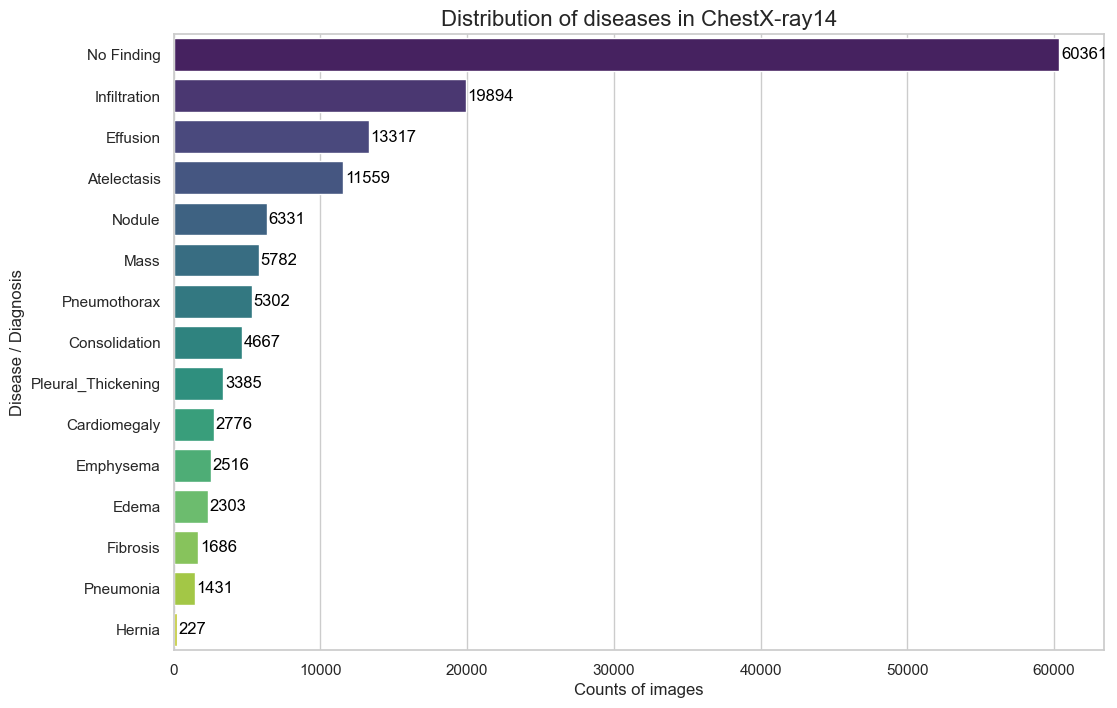

In [10]:
# count each type of diseases
label_counts = pd.Series(all_labels).value_counts()

plt.figure(figsize=(12, 8))
barplot = sns.barplot(
    x=label_counts.values,
    y=label_counts.index,
    hue=label_counts.index,
    palette='viridis',
    legend=False
)

plt.title("Distribution of diseases in ChestX-ray14", fontsize=16)
plt.xlabel("Counts of images", fontsize=12)
plt.ylabel("Disease / Diagnosis", fontsize=12)

for i, v in enumerate(label_counts.values):
    plt.text(v + 100, i, str(v), color='black', va='center')

plt.show()

Recommended weights (pos_weights) for model:
Atelectasis             8.699801
Cardiomegaly           39.389049
Consolidation          23.023998
Edema                  47.684325
Effusion                7.419314
Emphysema              43.562798
Fibrosis               65.500593
Hernia                492.920705
Infiltration            4.635870
Mass                   18.391214
No Finding              0.857491
Nodule                 16.709683
Pleural_Thickening     32.122600
Pneumonia              77.350804
Pneumothorax           20.146737
dtype: float64


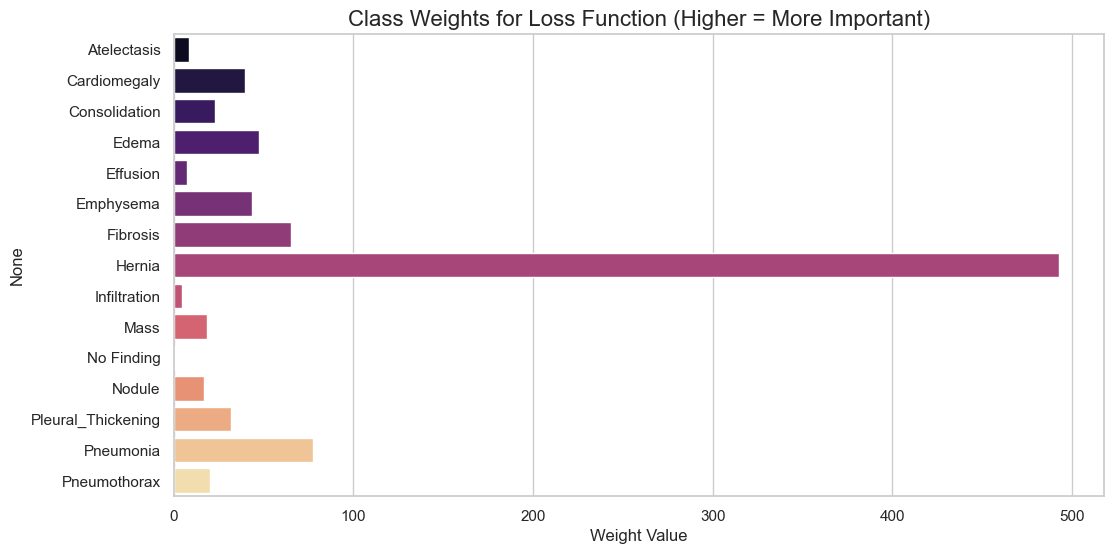

In [12]:
for label in unique_labels:
    df[label] = df['Finding Labels'].map(lambda x: 1.0 if label in x else 0.0)

N = df.shape[0]
label_counts = df[unique_labels].sum()

# Pos_Weight = (Total - Positive) / Positive
pos_weights = (N - label_counts) / label_counts

print(f"Recommended weights (pos_weights) for model:")
print(pos_weights)

plt.figure(figsize=(12, 6))
sns.barplot(x=pos_weights.values, y=pos_weights.index, hue=pos_weights.index, legend=False, palette='magma')
plt.title("Class Weights for Loss Function (Higher = More Important)", fontsize=16)
plt.xlabel("Weight Value")
plt.show()